# Ambiance — Model Training (Google Colab)
**Phase 4:** Train ResNet50 + custom head on the interior design dataset.

**Before running:** Make sure your Google Drive has this structure:
```
MyDrive/dl-project/
├── dataset_train/   ← 19 style subfolders
├── dataset_test/    ← 19 style subfolders
└── model.py
```
And confirm: **Runtime → Change runtime type → T4 GPU**

## 0. Mount Google Drive

In [ ]:
# Mounts your Google Drive at /content/drive/MyDrive — required to read the dataset and save the model.
# A browser popup will ask you to authorise access.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──────────────────────────────────────────────────────────────────────
DRIVE_DIR     = '/content/drive/MyDrive/dl-project'
TRAIN_DIR = '/content/dataset_train'
TEST_DIR  = '/content/dataset_test'
MODEL_PATH    = os.path.join(DRIVE_DIR, 'ambiance_model.h5')     # Best weights saved here
HISTORY_PATH  = os.path.join(DRIVE_DIR, 'training_history.json') # Training curves saved here
CURVES_PATH   = os.path.join(DRIVE_DIR, 'training_curves.png')   # Plot saved here

# Add Drive project folder to Python path so we can import model.py from Drive
sys.path.insert(0, DRIVE_DIR)

# Sanity checks — fix any that print False before continuing
print("GPU detected:      ", tf.config.list_physical_devices('GPU'))
print("Train dir exists:  ", os.path.exists(TRAIN_DIR))
print("Test dir exists:   ", os.path.exists(TEST_DIR))
print("model.py exists:   ", os.path.exists(os.path.join(DRIVE_DIR, 'model.py')))

GPU detected:       [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train dir exists:   False
Test dir exists:    False
model.py exists:    True


In [ ]:
import shutil

print("Copying dataset to local Colab storage — do this once per session...")
shutil.copytree('/content/drive/MyDrive/dl-project/dataset_train', '/content/dataset_train')
shutil.copytree('/content/drive/MyDrive/dl-project/dataset_test',  '/content/dataset_test')
print("Done.")


Copying dataset to local Colab storage — do this once per session...
Done.


## 1. Build data generators

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.15
SEED       = 42

# ResNet50 was trained with channel-mean subtraction (not simple /255 scaling).
# Using preprocess_input instead of rescale=1/255 is critical — the frozen base
# produces meaningful features only when it sees inputs in the same scale it was trained on.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    validation_split=VAL_SPLIT
)

# Evaluation generator — no augmentation so metrics reflect true real-world performance
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_gen.num_classes
assert NUM_CLASSES == 19, f"Expected 19 classes, got {NUM_CLASSES} — check for missing or misnamed folders on Drive."

print(f"Training images:   {train_gen.samples}")
print(f"Validation images: {val_gen.samples}")
print(f"Test images:       {test_gen.samples}")
print(f"Classes ({NUM_CLASSES}): {list(train_gen.class_indices.keys())}")

Found 12654 images belonging to 19 classes.
Found 2222 images belonging to 19 classes.
Found 3729 images belonging to 19 classes.
Training images:   12654
Validation images: 2222
Test images:       3729
Classes (19): ['asian', 'coastal', 'contemporary', 'craftsman', 'eclectic', 'farmhouse', 'french-country', 'industrial', 'mediterranean', 'mid-century-modern', 'modern', 'rustic', 'scandinavian', 'shabby-chic-style', 'southwestern', 'traditional', 'transitional', 'tropical', 'victorian']


## 2. Class balance check
If one class has far more images than others the model will be biased toward predicting it.
We compute class weights to compensate — the model penalises mistakes on smaller classes more heavily.

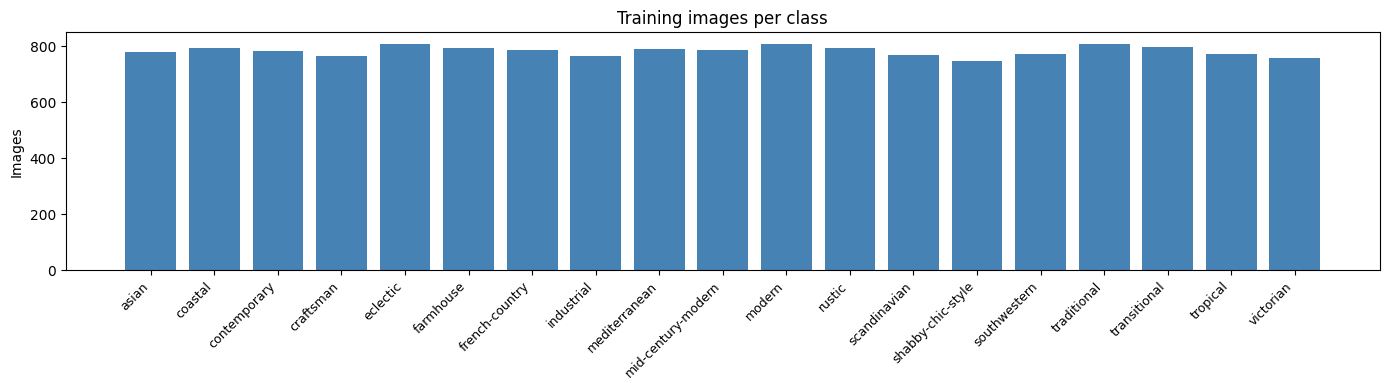

Min: 746  |  Max: 809  |  Ratio: 1.08x

Class weights (higher = model penalises mistakes more):
   0  asian                      weight: 1.005
   1  coastal                    weight: 0.987
   2  contemporary               weight: 1.002
   3  craftsman                  weight: 1.025
   4  eclectic                   weight: 0.968
   5  farmhouse                  weight: 0.985
   6  french-country             weight: 0.994
   7  industrial                 weight: 1.025
   8  mediterranean              weight: 0.993
   9  mid-century-modern         weight: 0.994
  10  modern                     weight: 0.968
  11  rustic                     weight: 0.987
  12  scandinavian               weight: 1.020
  13  shabby-chic-style          weight: 1.049
  14  southwestern               weight: 1.014
  15  traditional                weight: 0.968
  16  transitional               weight: 0.984
  17  tropical                   weight: 1.014
  18  victorian                  weight: 1.031


In [ ]:
class_names = list(train_gen.class_indices.keys())

# Count images per class folder directly from disk (before the val split)
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names]

plt.figure(figsize=(14, 4))
plt.bar(class_names, counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Images')
plt.title('Training images per class')
plt.tight_layout()
plt.show()

print(f"Min: {min(counts)}  |  Max: {max(counts)}  |  Ratio: {max(counts)/min(counts):.2f}x")

# compute_class_weight assigns higher weight to underrepresented classes.
# 'balanced' mode sets weight = total_samples / (num_classes * class_count), so rare classes get upweighted.
# This is passed to model.fit() so the loss function cares more about mistakes on smaller classes.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("\nClass weights (higher = model penalises mistakes more):")
for idx, name in enumerate(class_names):
    print(f"  {idx:>2}  {name:<25}  weight: {class_weight_dict[idx]:.3f}")

## 3. Build the model

## 4a. Train the custom head (frozen ResNet50 base)
In this phase only the custom ANN head is trained — the ResNet50 base stays frozen.
We train until val_loss stops improving, then move to fine-tuning.

## 4b. Fine-tune the top ResNet50 layers
Now that the custom head has learned to classify interior styles, we unfreeze the top 30 layers
of ResNet50 and continue training with a much lower learning rate.

**Why fine-tune?**
The frozen ResNet50 layers learned general image features (edges, textures) from ImageNet.
Fine-tuning lets those top layers also adapt to the specific visual patterns of interior design styles
(colour palettes, materials, structural elements) — pushing accuracy significantly higher.

**Why only the top 30 layers?**
Early ResNet layers detect universal low-level features (edges, gradients) that transfer perfectly.
Only the later layers need to adapt to our domain. Unfreezing all 175 layers with our dataset size would overfit.

**Why 1e-5 learning rate?**
10× lower than the head training rate. The ResNet weights are already good — we nudge them, not overwrite them.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load the saved model — weights and unfrozen layer state are preserved in the .h5
model = tf.keras.models.load_model(MODEL_PATH)

print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

# Recompile with fine-tuning learning rate (must recompile after loading to reset optimizer state)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_ft     = ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr_ft      = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

history_fine = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_ft, checkpoint_ft, reduce_lr_ft]
)

print(f"Phase 4b complete. Best val accuracy: {max(history_fine.history['val_accuracy'])*100:.1f}%")


Trainable layers: 37
Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.5414 - loss: 1.4724
Epoch 1: val_loss improved from None to 2.25790, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 328s 751ms/step - accuracy: 0.5351 - loss: 1.4912 - val_accuracy: 0.3335 - val_loss: 2.2579 - learning_rate: 1.0000e-05
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.5595 - loss: 1.4342
Epoch 2: val_loss did not improve from 2.25790
396/396 ━━━━━━━━━━━━━━━━━━━━ 294s 713ms/step - accuracy: 0.5567 - loss: 1.4290 - val_accuracy: 0.3231 - val_loss: 2.2809 - learning_rate: 1.0000e-05
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.5719 - loss: 1.3782
Epoch 3: val_loss did not improve from 2.25790
396/396 ━━━━━━━━━━━━━━━━━━━━ 275s 694ms/step - accuracy: 0.5702 - loss: 1.3876 - val_accuracy: 0.3308 - val_loss: 2.2634 - learning_rate: 1.0000e-05
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.5931 - loss: 1.3150
Epoch 4: val_loss did not improve from 2.25790

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.99999

## 5. Plot training curves
Both phases are plotted together. The vertical line marks where fine-tuning began.

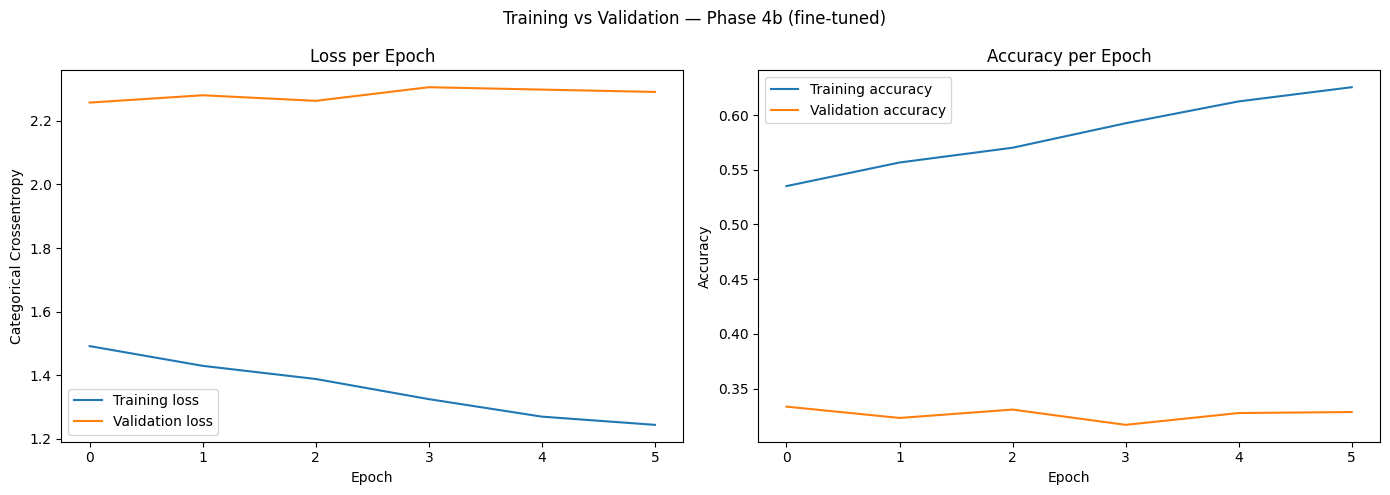

Curves saved to: /content/drive/MyDrive/dl-project/training_curves.png


In [ ]:
acc      = history_fine.history['accuracy']
val_acc  = history_fine.history['val_accuracy']
loss     = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss,     label='Training loss')
axes[0].plot(val_loss, label='Validation loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()

axes[1].plot(acc,     label='Training accuracy')
axes[1].plot(val_acc, label='Validation accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training vs Validation — Phase 4b (fine-tuned)', fontsize=12)
plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150)
plt.show()
print(f"Curves saved to: {CURVES_PATH}")

## 6. Save training history
Saves all metrics to a JSON file on Drive so you can re-plot curves in future sessions without retraining.

In [ ]:
full_history = {
    'accuracy':     acc,
    'val_accuracy': val_acc,
    'loss':         loss,
    'val_loss':     val_loss,
}

with open(HISTORY_PATH, 'w') as f:
    json.dump(full_history, f)

print(f"History saved to: {HISTORY_PATH}")

History saved to: /content/drive/MyDrive/dl-project/training_history.json


## 7. Final results

In [ ]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print(f"\n── Results ────────────────────────────────")
print(f"Fine-tuning epochs:  {len(history_fine.history['loss'])}")
print(f"Best val accuracy:   {max(val_acc)*100:.1f}%")
print(f"Test accuracy:       {test_acc*100:.1f}%")
print(f"Model saved to:      {MODEL_PATH}")
print(f"\nNext step: 03_evaluation.ipynb — F1 per class and confusion matrix.")

117/117 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.3411 - loss: 2.2235

── Results ────────────────────────────────
Fine-tuning epochs:  6
Best val accuracy:   33.3%
Test accuracy:       34.1%
Model saved to:      /content/drive/MyDrive/dl-project/ambiance_model.h5

Next step: 03_evaluation.ipynb — F1 per class and confusion matrix.
